# 🩺 HealthSense ML — Báo cáo tổng hợp

Notebook này là **cửa vào** của toàn bộ phần Machine Learning. Nó gồm hai nửa:

- **Phần A — Sản phẩm:** pipeline v4 đang chạy làm gì, và những con số nào
  bảo vệ được (3 tầng kiểm định).
- **Phần B — Hành trình:** vì sao bốn phiên bản trước công bố điểm cao hơn
  mà lại tệ hơn. Chứng minh bằng cách chạy lại cả 4 trên cùng một bộ dữ liệu.

Mọi con số đều **đọc từ kết quả đã chạy** trong `models/`, không huấn luyện
lại — mở ra là chạy được ngay trong vài giây.

**Mục lục**

| | Phần A — Sản phẩm | | Phần B — Hành trình |
|---|---|---|---|
| 1 | Bài toán & dữ liệu | 7 | Bốn phiên bản, bốn con số |
| 2 | Đặc trưng HRV — mô hình "nhìn" thấy gì | 8 | Vấn đề: một cái thước đo hỏng |
| 3 | Data leakage & cách đánh giá đúng | 9 | Chấm lại cả 4 bằng cùng một thước |
| 4 | Kết quả 3 tầng kiểm định | 10 | Vì sao v4 vẫn là tốt nhất |
| 5 | Kiểm chứng dò nhịp bằng ECG | 11 | Bốn loại rò rỉ đã gặp |
| 6 | Kết luận & giới hạn | 12 | Đọc tiếp |

> Mã nguồn: pipeline sản phẩm ở `src/healthsense_ml/`, bốn phiên bản ở
> `src/v1/` … `src/v4/`, tiện ích dùng chung ở `src/vlab/`.
> Giải thích mọi thuật ngữ: `docs/index.html` → tab *Giải thích thuật ngữ*.

In [1]:
import os, sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Notebook nam trong src/report/ -> thu muc goi la src/
CWD = os.path.abspath('')
SRC = os.path.dirname(CWD) if os.path.basename(CWD) == 'report' else CWD
if SRC not in sys.path:
    sys.path.insert(0, SRC)

from healthsense_ml import config          # pipeline san pham (Phan A)
from vlab import store, viz, honest        # bao tang phien ban (Phan B)

pd.set_option('display.width', 120)
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', lambda v: f'{v:.4f}')
%matplotlib inline
print('San sang. src =', SRC)

San sang. src = D:\Projects\HealthSense\HealthSense-MachineLearning-Lab\src


## 1. Bài toán & dữ liệu

**Mục tiêu:** phát hiện **Rung Nhĩ (AFib)** — loạn nhịp tim phổ biến nhất, tăng nguy cơ đột quỵ ~5 lần —
từ tín hiệu **PPG** (đo nhịp tim bằng ánh sáng, chính là cảm biến MAX30102 trên vòng HealthSense).

Dấu hiệu nhận biết AFib: **khoảng cách giữa các nhịp tim trở nên hỗn loạn, không theo quy luật**.
Vì vậy toàn bộ pipeline xoay quanh việc đo "độ hỗn loạn" đó.

Hai bộ dữ liệu công khai được dùng:

| Dataset | Loại tín hiệu | Bệnh nhân | Đặc điểm |
|---|---|---|---|
| MIMIC PERform AF | PPG kẹp ngón 125 Hz | 19 AFib + 16 Normal | Mỗi người 20 phút, có ECG đối chiếu |
| MIT-BIH AFDB | ECG 250 Hz | 25 người | ~10 giờ/người, **AF kịch phát** (lúc bệnh lúc thường) |

Mỗi bản ghi được cắt thành **cửa sổ 30 giây**; mỗi cửa sổ thành 1 hàng dữ liệu
kèm `record_id` — danh tính bệnh nhân, chìa khóa để đánh giá đúng (xem mục 3).

In [2]:
df = pd.read_csv(config.FEATURES_V4_FILE)
print(f'MIMIC: {len(df):,} cửa sổ từ {df.record_id.nunique()} bệnh nhân')
print(df.status.value_counts().rename({0: 'Normal', 1: 'AFib'}).to_string())
df.head(3)

MIMIC: 4,130 cửa sổ từ 35 bệnh nhân
status
AFib      2242
Normal    1888


,record_id,t_start,status,HR_mean,Mean_NN,SDNN,RMSSD,NN50,pNN50,CV,LF,HF,Total_Power,LF_HF_Ratio,LF_norm,HF_norm,SD1,SD2,SampEn
0,mimic_perform_af_001,0.0000,1,89.8938,667.4545,113.7982,175.9070,33,76.7442,0.1705,1380.3628,2706.8381,4728.3404,0.5100,33.7728,66.2272,125.8559,100.3012,1.9459
1,mimic_perform_af_001,10.0000,1,91.3907,656.5217,111.6235,155.0891,30,66.6667,0.1700,842.0663,3894.6632,5222.2671,0.2162,17.7774,82.2226,110.8801,112.3620,2.6391
2,mimic_perform_af_001,20.0000,1,91.3665,656.6957,105.4035,136.0157,26,57.7778,0.1605,991.0239,3989.2570,6031.2882,0.2484,19.8990,80.1010,97.2431,112.9760,2.9444


## 2. Đặc trưng HRV — mô hình "nhìn" thấy gì

Từ mỗi cửa sổ 30s, ta trích **chuỗi NN** (khoảng thời gian giữa 2 nhịp liên tiếp, ms)
rồi tính các con số mô tả nhịp — gọi là đặc trưng **HRV** (Heart Rate Variability):

- **Nhóm thời gian:** `RMSSD`, `pNN50`, `SDNN`… — nhịp càng loạn, số càng lớn.
- **Nhóm phi tuyến:** `SampEn` (độ "khó đoán" của chuỗi nhịp), `SD1/SD2` (hình dáng đồ thị Poincaré).
- **Nhóm tần số:** `HF`, `Total_Power`… (nhóm `LF` bị **loại** vì cửa sổ 30s quá ngắn để đo tin cậy).

Biểu đồ dưới cho thấy vì sao các đặc trưng này phân biệt được AFib — hai phân phối tách nhau rõ:

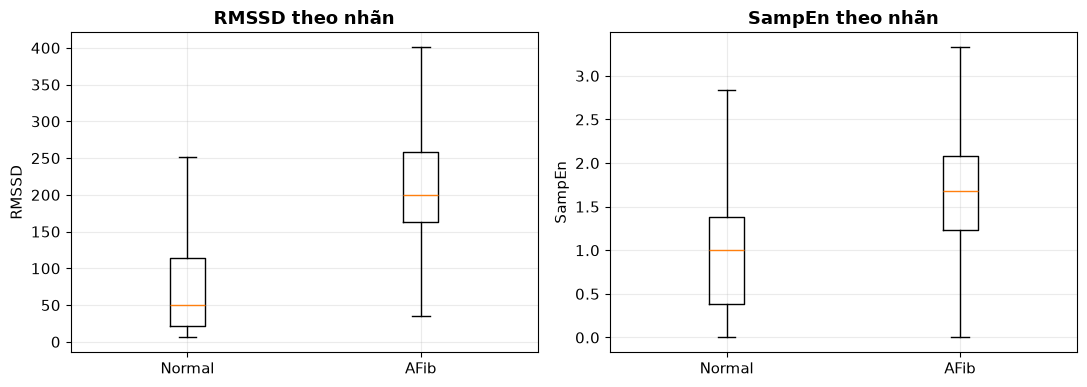

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, feat in zip(axes, ['RMSSD', 'SampEn']):
    data = [df[df.status == 0][feat], df[df.status == 1][feat]]
    ax.boxplot(data, tick_labels=['Normal', 'AFib'], showfliers=False)
    ax.set_title(f'{feat} theo nhãn')
    ax.set_ylabel(feat)
plt.tight_layout(); plt.show()

## 3. Data leakage & cách đánh giá đúng (LOSO)

**Vấn đề của pipeline cũ (v1–v3):** dữ liệu được chia train/test **ngẫu nhiên theo cửa sổ** —
các cửa sổ của *cùng một bệnh nhân* nằm ở cả 2 phía. Mô hình chỉ cần "nhận mặt bệnh nhân"
là đạt 98–99%, giống **học sinh được xem trước đề thi**. Con số đẹp nhưng ảo.

**Cách sửa (v4):** đánh giá bằng **LOSO** (Leave-One-Subject-Out) — có 35 bệnh nhân thì thi 35 vòng,
mỗi vòng **giấu trọn 1 bệnh nhân** làm đề thi, train trên 34 người còn lại. Kèm theo:
- Mọi tiền xử lý (chuẩn hóa, lọc outlier) chỉ được "học" từ phần train của từng vòng.
- Chọn cấu hình mô hình cũng chỉ dùng train (nested GroupKFold).

Điểm số LOSO trả lời đúng câu hỏi thực tế: *"gặp người **mới**, mô hình có nhận ra AFib không?"*

## 4. Kết quả 3 tầng kiểm định

### Tầng 1 — LOSO trên MIMIC (35 bệnh nhân)
Mức **bệnh nhân** = gộp trung bình mọi cửa sổ của một người thành 1 kết luận/người
(con số nên dùng để báo cáo, vì câu hỏi là "người này có bệnh không?"):

In [4]:
bench = pd.read_csv(f'{config.BENCHMARK_V4_DIR}/benchmark_results_v4.csv')
bench[bench.Level == 'subject'][['Model', 'Accuracy', 'Recall (Sensitivity)',
                                 'Specificity', 'F1-Score', 'ROC-AUC', 'FN', 'FP']]

,Model,Accuracy,Recall (Sensitivity),Specificity,F1-Score,ROC-AUC,FN,FP
1,Logistic Regression,0.9429,1.0000,0.8750,0.9500,0.8750,0,2
3,Random Forest,0.9429,1.0000,0.8750,0.9500,0.9309,0,2
5,XGBoost,0.9429,1.0000,0.8750,0.9500,0.9013,0,2


**Đọc kết quả:** `Recall = 1.0` nghĩa là **bắt đủ cả 19 bệnh nhân AFib, không sót ai** (FN = 0).
2 ca báo nhầm (FP) là cùng 2 bệnh nhân "Normal" đặc biệt — được giải mã ở mục 5.

### Tầng 2 — Cross-dataset: bài thi khắc nghiệt nhất
Train trên dataset này, test **toàn bộ** dataset kia — khác bệnh viện, khác loại cảm biến (PPG vs ECG),
khác quần thể. Mô hình giữ được điểm = bằng chứng nó học "dấu hiệu bệnh" chứ không học vẹt:

In [5]:
cross = pd.read_csv(f'{config.MODELS_DIR}/cross_dataset/cross_dataset_results.csv')
cross[['Direction', 'Model', 'Accuracy', 'Recall (Sensitivity)', 'Specificity', 'ROC-AUC']]

,Direction,Model,Accuracy,Recall (Sensitivity),Specificity,ROC-AUC
0,MIMIC -> AFDB,Logistic Regression,0.9384,0.9651,0.9215,0.9721
1,MIMIC -> AFDB,Random Forest,0.9383,0.9563,0.9269,0.9846
2,MIMIC -> AFDB,XGBoost,0.9456,0.9699,0.9303,0.9870
3,AFDB -> MIMIC,Logistic Regression,0.9123,0.9701,0.8438,0.8761
4,AFDB -> MIMIC,Random Forest,0.9186,0.9737,0.8533,0.9757
5,AFDB -> MIMIC,XGBoost,0.9145,0.9755,0.8422,0.9685


AUC giữ ~**0.97–0.99 theo cả 2 chiều** — mức tổng quát hóa rất mạnh.

### Tầng 3 — Model triển khai: gộp 60 bệnh nhân
Gộp cả 2 dataset (cân bằng nguồn bằng sample weight để AFDB 29k cửa sổ không "đè" MIMIC 4k),
đánh giá pooled LOSO 60 vòng, rồi train model cuối trên toàn bộ và xuất `.pkl`:

In [6]:
pooled = pd.read_csv(f'{config.MODELS_DIR}/final/pooled_loso_results.csv')
display(pooled[(pooled.Level == 'window') & (pooled.Subset == 'pooled')]
        [['Model', 'Accuracy', 'Recall (Sensitivity)', 'Specificity', 'ROC-AUC']])

card = json.load(open(f'{config.MODELS_DIR}/final/model_card.json', encoding='utf-8'))
print('Model triển khai:', card['model'], '| version', card['version'])
print('File:', 'models/final/healthsense_afib_pipeline.pkl')
print('Giới hạn:', card['limitations'])

,Model,Accuracy,Recall (Sensitivity),Specificity,ROC-AUC
0,Logistic Regression,0.9478,0.9733,0.9304,0.9700
4,Random Forest,0.9525,0.9655,0.9436,0.9876
8,XGBoost,0.9589,0.9716,0.9501,0.9883


Model triển khai: XGBoost | version 4.1.0
File: models/final/healthsense_afib_pipeline.pkl
Giới hạn: Chưa kiểm định trên PPG cổ tay (MAX30102) và dữ liệu ngoài bệnh viện. Không phải thiết bị chẩn đoán y tế.


## 5. Kiểm chứng dò nhịp bằng ECG & giải mã 2 ca đặc biệt

Toàn bộ đặc trưng phụ thuộc việc **dò nhịp trên PPG có chính xác không**. May mắn MIMIC có cột ECG
ghi song song — dùng R-peak trên ECG làm "đáp án chuẩn" chấm điểm bộ dò nhịp PPG:

In [7]:
bv = pd.read_csv(f'{config.MODELS_DIR}/beat_validation/beat_validation.csv')
print('F1 dò nhịp (median):')
print(bv.groupby('label').f1.median().to_string())
print()
suspects = bv[bv.record_id.isin(['mimic_perform_non_af_012', 'mimic_perform_non_af_014'])]
suspects[['record_id', 'label', 'f1', 'hr_mae_bpm', 'ecg_RMSSD', 'ecg_pNN50']]

F1 dò nhịp (median):
label
AFib     0.8548
Normal   0.9908



,record_id,label,f1,hr_mae_bpm,ecg_RMSSD,ecg_pNN50
30,mimic_perform_non_af_012,Normal,0.3550,29.9000,233.4632,40.6504
32,mimic_perform_non_af_014,Normal,0.1957,23.9500,30.6060,1.5365


**Giải mã 2 bệnh nhân "Normal" bị mô hình báo AFib** (nhìn thẳng vào ECG của họ):

- `non_af_012`: RMSSD tính từ **chính ECG** = 233 ms — còn loạn hơn median nhóm AFib (170 ms).
  → Tim người này loạn thật; **nhãn "Normal" của dataset đáng nghi**, mô hình báo có cơ sở.
- `non_af_014`: RMSSD từ ECG chỉ 31 ms (tim hoàn toàn bình thường) nhưng **PPG hỏng nặng**
  (F1 dò nhịp 0.196, sai số HR 24 bpm). → Mô hình "ăn" phải nhịp rác từ tín hiệu xấu.
  Đây là lý do AI-Service bổ sung **SQI** — tín hiệu kém thì từ chối phân loại thay vì đoán bừa.

Ngoài ra, so **kết quả đo PPG vs ECG cùng thời điểm** trên 1.400 cửa sổ: nhịp tim lệch trung bình
chỉ ~3.5 bpm (r = 0.94) — PPG đủ tin cậy để đo HR và sàng lọc AFib; riêng giá trị HRV tuyệt đối
thì PPG "phóng đại" so với ECG (hiện tượng PRV ≠ HRV kinh điển trong y văn).

## 6. Kết luận & giới hạn

**Kết luận:**
- Pipeline v4 sạch leakage, kiểm định 3 tầng; con số bảo vệ được: LOSO 94.3% / Recall 100%,
  cross-dataset AUC 0.976–0.987, pooled 60 bệnh nhân 95.9% / AUC 0.988.
- Model triển khai (`healthsense_afib_pipeline.pkl`) đã tích hợp vào `HealthSense-AI-Service`
  kèm parity test (service tính giống hệt lab) và SQI.

**Giới hạn cần ghi rõ khi báo cáo:**
- Dataset nhỏ (60 bệnh nhân) → khoảng tin cậy rộng; 2 record MIMIC nghi vấn (nhãn/chất lượng).
- Chưa kiểm định trên **PPG cổ tay MAX30102** ngoài đời thực — bước tiếp theo quan trọng nhất.
- Không phải thiết bị chẩn đoán y tế; kết quả chỉ phục vụ sàng lọc/nghiên cứu.

---

# Phần B — Hành trình: bốn phiên bản, một bài học

Phần A vừa trình bày con số của pipeline hiện hành: **94.3% mức bệnh nhân,
recall 100%**.

Nhưng ba phiên bản trước đó từng công bố **95.9%, 97.4% và 98.7%** — đều cao
hơn. Nếu chỉ nhìn điểm số, v4 trông như một bước lùi.

Mục 3 ở trên đã giải thích *khái niệm* data leakage. Phần B **chứng minh nó
bằng số**: chạy lại cả bốn phiên bản trên cùng một bộ dữ liệu, chấm bằng cùng
một thước đo, rồi đặt cạnh nhau.

## 7. Bốn phiên bản, bốn con số

Bốn phiên bản pipeline, điểm số công bố lần lượt là:

| Phiên bản | Điểm công bố ngày đó |
|---|---|
| v1 | 95.9% |
| v2 | 97.4% |
| v3 | **98.7%** |
| v4 | **94.3%** |

Nhìn bảng này, ai cũng sẽ nghĩ v3 là phiên bản tốt nhất và v4 là một bước lùi.

Sự thật ngược lại: **v3 là phiên bản tệ nhất, v4 là phiên bản duy nhất dùng được.**

Notebook này giải thích vì sao — và quan trọng hơn, chứng minh bằng cách chạy
lại cả 4 phiên bản trên **cùng một bộ dữ liệu, cùng một thước đo**.

## 8. Vấn đề: một cái thước đo hỏng

Tưởng tượng bạn dạy học sinh rồi ra đề kiểm tra. Nếu đề kiểm tra gồm **đúng
những câu đã chữa trên lớp**, điểm sẽ rất cao — nhưng con số đó không cho biết
học sinh có làm được bài mới hay không.

Ba phiên bản đầu mắc đúng lỗi này, gọi là **data leakage** (rò rỉ dữ liệu):
thông tin từ tập kiểm tra bị lọt vào quá trình học.

Cụ thể ở đây: mỗi bệnh nhân đóng góp hàng chục "cửa sổ" 30 giây. Khi trộn tất
cả cửa sổ rồi bốc ngẫu nhiên 20% làm đề kiểm tra, gần như chắc chắn mỗi người
trong đề kiểm tra **cũng có mặt trong bài giảng**. Mô hình chỉ cần nhớ mặt
bệnh nhân là đủ điểm cao — không cần hiểu AFib là gì.

Cách chữa gọi là **LOSO** (Leave-One-Subject-Out — giữ một người ra ngoài):
mỗi vòng cất trọn một bệnh nhân đi, học trên những người còn lại, rồi kiểm tra
trên đúng người chưa từng gặp. Đây mới là mô phỏng đúng tình huống sản phẩm
gặp một người lạ.

## 9. Chấm lại cả 4 phiên bản bằng cùng một thước

Mỗi thư mục `src/vN/` đã chạy xong và lưu kết quả vào `models/vN/results.json`.
Nạp lên và xếp cạnh nhau.

In [8]:
versions = ['v1', 'v2', 'v3', 'v4']
R = {v: store.load(v) for v in versions}

missing = [v for v, r in R.items() if r is None]
if missing:
    print('Chua co ket qua cho:', missing, '-> chay: python src/<v>/pipeline.py')

rows = []
for v in versions:
    r = R[v]
    leaky = r.get('reproduced_leaky') or r.get('if_graded_the_old_way')
    rows.append({
        'Phiên bản': v,
        'Nội dung': r['title'],
        'Cửa sổ': r['data']['n_windows'],
        'Đặc trưng': r['config']['n_features'],
        'Chấm kiểu cũ': leaky['accuracy'],
        'Chấm bằng LOSO': r['regraded_loso_window']['accuracy'],
        'Điểm ảo': r['inflation'],
    })

bang = pd.DataFrame(rows)
bang

,Phiên bản,Nội dung,Cửa sổ,Đặc trưng,Chấm kiểu cũ,Chấm bằng LOSO,Điểm ảo
0,v1,Đường cơ sở MIMIC PPG,1400,13,0.9821,0.9207,0.0614
1,v2,Làm sạch dữ liệu + đặc trưng phi tuyến,1400,16,0.9889,0.9257,0.0632
2,v3,Benchmark đa quy mô trên kênh ECG,4130,16,0.9919,0.9199,0.0720
3,v4,"Pipeline hiện hành (LOSO, chống leakage)",4130,13,0.9806,0.9167,0.0639


### Đọc bảng trên

Cột **"Chấm kiểu cũ"** là cách v1–v3 tự chấm điểm cho mình: chia ngẫu nhiên
theo cửa sổ. Cột **"Chấm bằng LOSO"** là chấm trung thực theo bệnh nhân.

Hai điều đập vào mắt:

1. **Cột "chấm kiểu cũ" tăng dần qua các phiên bản** — đúng như lịch sử ghi
   nhận. Trông như tiến bộ thật.
2. **Cột "chấm bằng LOSO" gần như đứng yên quanh 92%** ở cả bốn phiên bản.

Nghĩa là: mọi "tiến bộ" từ v1 lên v3 chỉ tồn tại trong cái thước đo hỏng.
Khi đo bằng thước thật, bốn phiên bản giỏi ngang nhau.

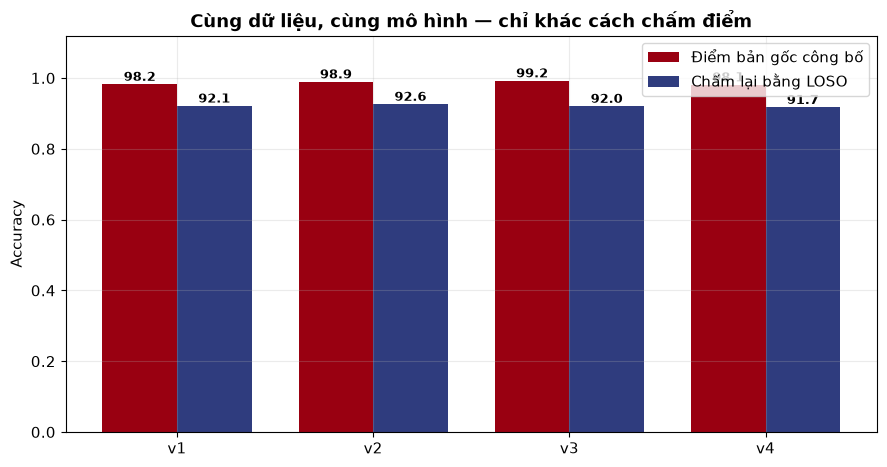

In [9]:
fig = viz.version_comparison([
    {'version': r['Phiên bản'], 'claimed': r['Chấm kiểu cũ'], 'honest': r['Chấm bằng LOSO']}
    for r in bang.to_dict(orient='records')
], title='Cùng dữ liệu, cùng mô hình — chỉ khác cách chấm điểm')
plt.show()

## 10. Vì sao v4 vẫn là phiên bản tốt nhất?

Nếu cả bốn đều ~92% khi chấm trung thực, tại sao lại nói v4 hơn hẳn?

Vì **92% của v4 là con số nó tự công bố**, còn 92% của v1–v3 là con số ta
phải đi chấm lại giúp. Ba phiên bản đầu tin rằng mình đạt 95–99%. Nếu đem
niềm tin đó ra quyết định — chọn ngưỡng cảnh báo, hứa hẹn với bác sĩ, thiết
kế sản phẩm — thì mọi thứ dựng trên một con số sai lệch 6–7 điểm.

Ngoài ra v4 còn hai thứ v1–v3 hoàn toàn không có:

- **Kiểm định chéo bộ dữ liệu**: học trên MIMIC rồi đi thi trên AFDB (bộ dữ
  liệu khác, thiết bị khác, loại tín hiệu khác) — AUC 0.987. Đây là bằng chứng
  mô hình học "dấu hiệu của AFib" chứ không phải "đặc điểm của bộ dữ liệu".
- **Metric mức bệnh nhân**: gộp toàn bộ cửa sổ của một người thành một chẩn
  đoán. Bác sĩ chẩn đoán con người, không chẩn đoán từng đoạn 30 giây.

In [10]:
sub_rows = []
for v in versions:
    s = R[v].get('regraded_loso_subject') or {}
    if s:
        sub_rows.append({
            'Phiên bản': v,
            'Số bệnh nhân': s.get('n_subjects'),
            'Accuracy': s.get('accuracy'),
            'Recall (bắt được AFib)': s.get('recall'),
            'Specificity (không báo oan)': s.get('specificity'),
        })
pd.DataFrame(sub_rows)

,Phiên bản,Số bệnh nhân,Accuracy,Recall (bắt được AFib),Specificity (không báo oan)
0,v1,35,0.9429,1.0000,0.8750
1,v2,35,0.9429,1.0000,0.8750
2,v3,35,0.9714,1.0000,0.9375
3,v4,35,0.9429,1.0000,0.8750


### Khoan — vì sao v3 lại cao hơn v4 ở mức bệnh nhân?

Bảng trên có một chỗ dễ gây hiểu nhầm: **v3 đạt ~97% mức bệnh nhân, cao hơn
v4 (~94%)**. Vậy chẳng phải v3 tốt hơn thật sao?

Không. Lý do nằm ở **loại tín hiệu**, không phải ở phương pháp:

- v3 trích đặc trưng từ kênh **ECG** (điện tâm đồ) — tín hiệu sạch, đỉnh sóng
  R rất nhọn và dễ dò, gần như không nhiễu.
- v1, v2, v4 dùng kênh **PPG** (cảm biến quang) — đúng loại cảm biến trên vòng
  đeo tay, nhưng khó hơn nhiều: sóng tù, dễ nhiễu vì cử động và áp lực tiếp xúc.

Đo bằng ECG rồi khoe điểm cao, trong khi sản phẩm chạy bằng PPG, là so sánh
khập khiễng. **Đây chính là một trong những vấn đề của v3**, chứ không phải
điểm cộng: nó khiến mọi con số của v3 không nói lên điều gì về sản phẩm thật.

Muốn so công bằng thì phải so trên cùng loại tín hiệu — và khi đó v1/v2/v4
(cùng dùng PPG) đều quanh 94% mức bệnh nhân, ngang nhau.

## 11. Bốn loại rò rỉ đã gặp

Mỗi phiên bản thêm một kiểu rò rỉ mới, chồng lên kiểu cũ:

| # | Kiểu rò rỉ | Xuất hiện | Bản chất |
|---|---|---|---|
| 1 | Chia ngẫu nhiên theo cửa sổ | v1 | Người ở đề thi cũng có trong bài giảng |
| 2 | Làm sạch dựa trên nhãn, áp lên cả test | v2 | Xóa những câu khó khỏi đề thi |
| 3 | Chọn ngưỡng bằng điểm test | v2 | Nhìn trộm đáp án để chỉnh tham số |
| 4 | Chuẩn hóa / lọc IQR trên toàn bộ dữ liệu | v3 | Thông tin phân bố của test lọt vào train |
| 5 | Cửa sổ chồng lấn + chia ngẫu nhiên | v3 | Bản sao gần đúng của câu hỏi nằm trong bài giảng |

**Một hiểu nhầm cần tránh:** cửa sổ chồng lấn *tự nó* không phải lỗi. v4 vẫn
dùng bước trượt 10 giây (chồng 67%). Nó chỉ nguy hiểm khi **đi kèm chia ngẫu
nhiên**. Với LOSO, mọi cửa sổ của một người nằm trọn về một phía, chồng lấn
bao nhiêu cũng không vượt được ranh giới.

In [11]:
for v in versions:
    r = R[v]
    print(f"\n{'='*66}\n{v} — {r['title']}\n{'='*66}")
    items = r.get('leakage') or []
    if items:
        for i, x in enumerate(items, 1):
            print(f'  ❌ {i}. {x}')
    for x in (r.get('fixes') or []):
        print(f'  ✅ {x}')


v1 — Đường cơ sở MIMIC PPG
  ❌ 1. Chia ngẫu nhiên theo cửa sổ: bệnh nhân ở test cũng có trong train (subject leakage).

v2 — Làm sạch dữ liệu + đặc trưng phi tuyến
  ❌ 1. Chia ngẫu nhiên theo cửa sổ (kế thừa v1).
  ❌ 2. Luật làm sạch dùng NHÃN và áp lên cả tập test -> xóa mất các ca khó.
  ❌ 3. Ngưỡng SQI được chọn bằng điểm test (xem sqi_threshold_sweep).

v3 — Benchmark đa quy mô trên kênh ECG
  ❌ 1. Cửa sổ chồng lấn tới 92%: bản sao gần đúng của mẫu test nằm trong train.
  ❌ 2. StandardScaler fit trên toàn bộ dữ liệu trước khi chia.
  ❌ 3. Lọc IQR tính ngưỡng trên toàn bộ bảng, xóa cả ca khó trong test.
  ❌ 4. Chia ngẫu nhiên theo cửa sổ, không theo bệnh nhân.
  ❌ 5. Trích đặc trưng từ kênh ECG — không phải PPG như sản phẩm thật.

v4 — Pipeline hiện hành (LOSO, chống leakage)
  ✅ LOSO theo bệnh nhân: người ở test chưa từng xuất hiện trong train.
  ✅ Scaler fit lại theo từng fold, chỉ nhìn dữ liệu train.
  ✅ Lọc IQR tính trên train và chỉ xóa hàng train; test giữ nguyên 100%.
  ✅ Ti

## 12. Đọc tiếp

Bốn báo cáo chi tiết, mỗi phiên bản một notebook:

| Notebook | Nội dung |
|---|---|
| [`01_v1_report.ipynb`](01_v1_report.ipynb) | Đường cơ sở — và bằng chứng 100% bệnh nhân test nằm trong train |
| [`02_v2_report.ipynb`](02_v2_report.ipynb) | Khi "làm sạch dữ liệu" biến thành xóa câu khó khỏi đề thi |
| [`03_v3_report.ipynb`](03_v3_report.ipynb) | Bốn lỗi chồng nhau, và quy luật "càng chồng lấn điểm giả càng đẹp" |
| [`04_v4_report.ipynb`](04_v4_report.ipynb) | Cách chữa, và vì sao chấp nhận điểm thấp hơn |

Mã nguồn từng phiên bản ở `src/v1/` … `src/v4/`, mỗi thư mục có README riêng
dạng "thẻ phiên bản" ghi rõ cấu hình, chỗ đúng, chỗ sai. Chạy lại một phiên
bản bất kỳ:

```bash
python src/v1/pipeline.py
```